In [1]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import time
import pickle

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fn_NN = '../../Active_SAM_joined/SAM_DR_nonneural_cleaned_07212026.h5ad'
sam_NN = SAM()
sam_NN.load_data(fn_NN)

In [3]:
fn = '../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad'
sam = SAM()
sam.load_data(fn)

In [4]:
sam.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'eq_subclass',
       'eq_subclass_lc', 'leiden_clusters', 'eq_subclass_nounlabeled',
       'ss_subclass', 'ss_subclass_v4_nounlabeled',
       'ss_subclass_v4_nounlabeled_nn', 'ss_subclass_nounlabeled_nmm_v4_nn',
       'ss_subclass_nounlabeled_nmm_v4_nn_thresh30',
       'ss_subclass_nounlabeled_nmm_cl_v4_nn'],
      dtype='object')

In [5]:
sm = load_samap('../../Active_SAMap_Joined/sm_hypo_nonneural_07262026.pkl')

In [6]:
org_one = 'mg'
org_two = 'dr'

In [7]:
sm.sams[org_two].adata.obs_names.equals(sam_NN.adata.obs_names)

True

In [8]:
sm.sams[org_two].clustering(param = 2)

In [9]:
level_one = 'subclass_id_label'
level_two = 'leiden_clusters'

In [10]:
keys = {org_one:level_one,org_two:level_two}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable =  MappingTable.loc[:,[i for i in MappingTable.columns if i[:2] == org_one]]
lim_MappingTable = lim_MappingTable.loc[[i for i in lim_MappingTable.index if i[:2] == org_two],:]

/scratch/miniconda/lib/python3.7/site-packages/samap/analysis.py:1609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  samap.adata.obs[l] = pd.Categorical(cl)


In [11]:
df = pd.read_csv('../../OTO_star_nothreshold_missing_le2_expressionthresh_08022026.tsv',delimiter='\t', index_col = 'Unnamed: 0')

In [12]:
df.loc[df.index[np.where(df['MM'] == 'Gfap')],:]

,MM,MO,CJ,AC,XT,DR
49511@7742,Gfap,Gfap,GFAP,gfap,NaN,gfap


In [11]:
new_mapping = {}
for item in lim_MappingTable.index:
    if np.max(lim_MappingTable.loc[item,:]) > .2 and len(sm.sams[org_two].adata[sm.sams[org_two].adata.obs[level_two] == int(item[3:])]) > 25:
        new_mapping[item] = lim_MappingTable.loc[item,:].idxmax()[3:]
        if np.max(lim_MappingTable.loc[item,:])/lim_MappingTable.loc[item,:].nlargest(2).iloc[-1] < 2 and np.max(lim_MappingTable.loc[item,:]) - lim_MappingTable.loc[item,:].nlargest(2).iloc[-1] < 0.2:
            print(item,lim_MappingTable.loc[item,:].idxmax())
    else:
        print('Unmapped ' + item, len(sm.sams[org_two].adata[sm.sams[org_two].adata.obs['leiden_clusters'] == int(item[3:])]))

Unmapped dr_10 537
Unmapped dr_12 513
dr_13 mg_337 DC NN
Unmapped dr_23 201
dr_24 mg_331 Peri NN
dr_3 mg_338 Lymphoid NN
Unmapped dr_31 81
Unmapped dr_32 80
Unmapped dr_34 45
dr_4 mg_319 Astro-TE NN
dr_7 mg_320 Astro-OLF NN
dr_8 mg_316 Bergmann NN


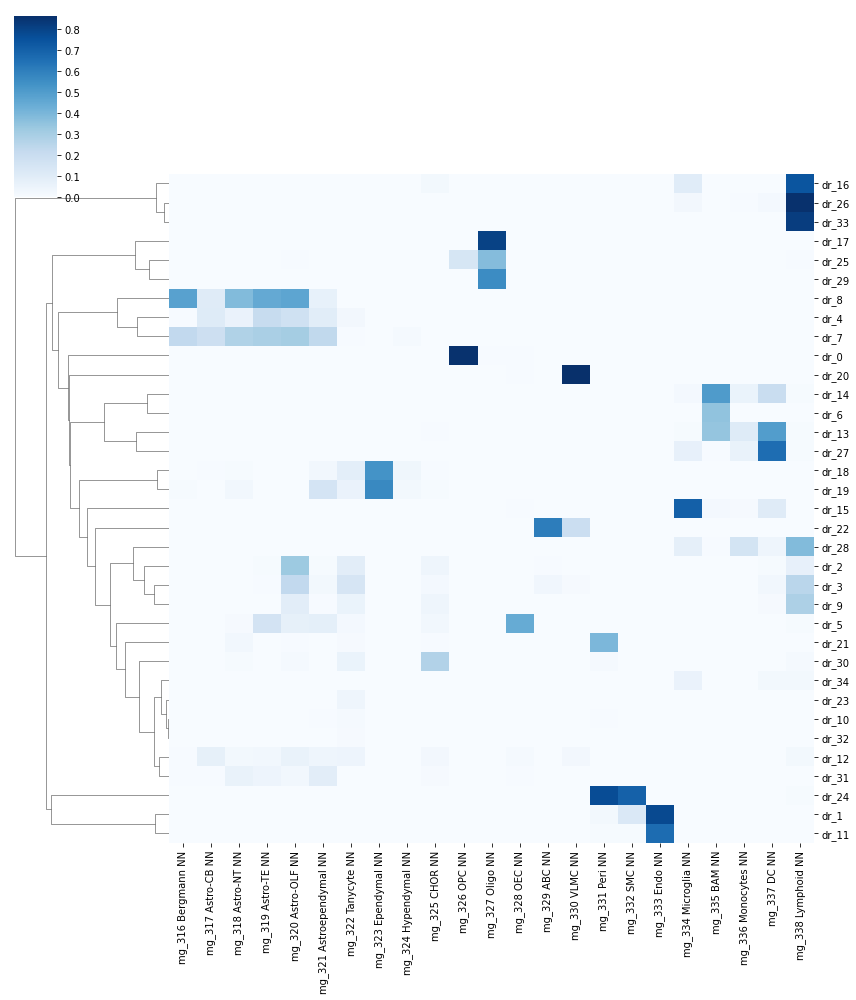

In [12]:
g = sns.clustermap(lim_MappingTable, col_cluster = False, method = 'ward', cmap = 'Blues',figsize = (12,14))
row_order = g.dendrogram_row.reordered_ind 

In [13]:
row_ord_plt = [int(i[3:]) for i in lim_MappingTable.index[row_order]]

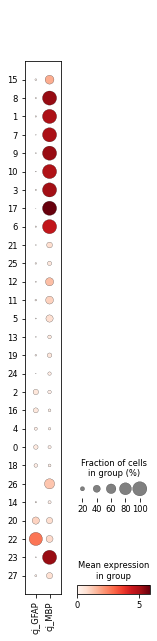

In [16]:
sc.pl.dotplot(sm.sams[org_two].adata, ['cj_GFAP','cj_MBP'], groupby = 'leiden_clusters', categories_order=row_ord_plt)

In [14]:
new_mapping

{'dr_0': '326 OPC NN',
 'dr_1': '333 Endo NN',
 'dr_11': '333 Endo NN',
 'dr_13': '337 DC NN',
 'dr_14': '335 BAM NN',
 'dr_15': '334 Microglia NN',
 'dr_16': '338 Lymphoid NN',
 'dr_17': '327 Oligo NN',
 'dr_18': '323 Ependymal NN',
 'dr_19': '323 Ependymal NN',
 'dr_2': '320 Astro-OLF NN',
 'dr_20': '330 VLMC NN',
 'dr_21': '331 Peri NN',
 'dr_22': '329 ABC NN',
 'dr_24': '331 Peri NN',
 'dr_25': '327 Oligo NN',
 'dr_26': '338 Lymphoid NN',
 'dr_27': '337 DC NN',
 'dr_28': '338 Lymphoid NN',
 'dr_29': '327 Oligo NN',
 'dr_3': '338 Lymphoid NN',
 'dr_30': '325 CHOR NN',
 'dr_33': '338 Lymphoid NN',
 'dr_4': '319 Astro-TE NN',
 'dr_5': '328 OEC NN',
 'dr_6': '335 BAM NN',
 'dr_7': '320 Astro-OLF NN',
 'dr_8': '316 Bergmann NN',
 'dr_9': '338 Lymphoid NN'}

In [15]:
lim_MappingTable.columns

Index(['mg_316 Bergmann NN', 'mg_317 Astro-CB NN', 'mg_318 Astro-NT NN',
       'mg_319 Astro-TE NN', 'mg_320 Astro-OLF NN', 'mg_321 Astroependymal NN',
       'mg_322 Tanycyte NN', 'mg_323 Ependymal NN', 'mg_324 Hypendymal NN',
       'mg_325 CHOR NN', 'mg_326 OPC NN', 'mg_327 Oligo NN', 'mg_328 OEC NN',
       'mg_329 ABC NN', 'mg_330 VLMC NN', 'mg_331 Peri NN', 'mg_332 SMC NN',
       'mg_333 Endo NN', 'mg_334 Microglia NN', 'mg_335 BAM NN',
       'mg_336 Monocytes NN', 'mg_337 DC NN', 'mg_338 Lymphoid NN'],
      dtype='object')

In [18]:
#Mapping CJ
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN',
                  '334 Microglia NN':'340 Macrophage NN', '335 BAM NN':'340 Macrophage NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs[level_two]:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [18]:
#Mapping AC
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN',
                  '334 Microglia NN':'340 Macrophage NN', '335 BAM NN':'340 Macrophage NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs[level_two]:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [17]:
#Mapping XT
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN',
                  '334 Microglia NN':'340 Macrophage NN', '335 BAM NN':'340 Macrophage NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs[level_two]:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [16]:
#Mapping DR
grouped_mapping = {'316 Bergmann NN':'339 Astrocyte-like NN','317 Astro-CB NN':'339 Astrocyte-like NN','318 Astro-NT NN':'339 Astrocyte-like NN','319 Astro-TE NN':'339 Astrocyte-like NN','320 Astro-OLF NN':'339 Astrocyte-like NN',
                  '334 Microglia NN':'340 Macrophage NN', '335 BAM NN':'340 Macrophage NN'}
fin_mapping =[]
for item in sm.sams[org_two].adata.obs[level_two]:
    if org_two + '_' + str(item) not in new_mapping:
        fin_mapping.append('Unlabeled')
    else:
        if new_mapping[org_two + '_' + str(item)] not in grouped_mapping:
            fin_mapping.append(new_mapping[org_two + '_' + str(item)])
        else:
            fin_mapping.append(grouped_mapping[new_mapping[org_two + '_' + str(item)]])
fin_mapping = pd.Series(fin_mapping, index=sm.sams[org_two].adata.obs_names)

In [17]:
sm.sams[org_two].adata.obs['ss_subclass_v4_nounlabeled_nn'] = fin_mapping
sm.sams[org_two].adata.obs['leiden_clusters_nonneuron'] = sm.sams[org_two].adata.obs['leiden_clusters']

In [18]:
sam_NN.adata.obs['ss_subclass_v4_nounlabeled_nn'] = fin_mapping
sam_NN.adata.obs['leiden_clusters_nonneuron'] = sm.sams[org_two].adata.obs['leiden_clusters']

In [19]:
np.sort(sm.sams[org_two].adata.obs['ss_subclass_v4_nounlabeled_nn'].unique())

array(['323 Ependymal NN', '325 CHOR NN', '326 OPC NN', '327 Oligo NN',
       '328 OEC NN', '329 ABC NN', '330 VLMC NN', '331 Peri NN',
       '333 Endo NN', '337 DC NN', '338 Lymphoid NN',
       '339 Astrocyte-like NN', '340 Macrophage NN', 'Unlabeled'],
      dtype=object)

In [20]:
np.sort(sam_NN.adata.obs['ss_subclass_v4_nounlabeled_nn'].unique())

array(['323 Ependymal NN', '325 CHOR NN', '326 OPC NN', '327 Oligo NN',
       '328 OEC NN', '329 ABC NN', '330 VLMC NN', '331 Peri NN',
       '333 Endo NN', '337 DC NN', '338 Lymphoid NN',
       '339 Astrocyte-like NN', '340 Macrophage NN', 'Unlabeled'],
      dtype=object)

In [21]:
sm.sams[org_two].adata

AnnData object with n_obs × n_vars = 14345 × 25503
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'eq_subclass', 'eq_subclass_lc', 'leiden_clusters', 'eq_subclass_nounlabeled', 'ss_subclass', 'ss_subclass_v4_nounlabeled', 'ss_subclass_v4_nounlabeled_nn', 'leiden_clusters_nonneuron'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions', 'mean_correction'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap', 'X_umap_samap'
    varm: 'PCs', 'PCs_SAMap'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [22]:
sam_NN.adata

AnnData object with n_obs × n_vars = 14345 × 25503
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'eq_subclass', 'eq_subclass_lc', 'leiden_clusters', 'eq_subclass_nounlabeled', 'ss_subclass', 'ss_subclass_v4_nounlabeled', 'ss_subclass_v4_nounlabeled_nn', 'leiden_clusters_nonneuron'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [23]:
fin_labels = []
for item in sam.adata.obs_names:
    if item in sm.sams[org_two].adata.obs_names:
        fin_labels.append(sm.sams[org_two].adata.obs.loc[item,'ss_subclass_v4_nounlabeled_nn'])
    else:
        fin_labels.append(sam.adata.obs.loc[item,'ss_subclass_v4_nounlabeled'])
fin_labels = pd.Series(fin_labels, index=sam.adata.obs_names)
sam.adata.obs['ss_subclass_v4_nounlabeled_nn'] = fin_labels

In [24]:
np.sort(sam.adata.obs['ss_subclass_v4_nounlabeled_nn'].unique())

array(['041 OB-in Frmd7 Gaba', '045 OB-STR-CTX Inh IMN', '049 Lamp5 Gaba',
       '054 STR Prox1 Lhx6 Gaba', '056 Sst Chodl Gaba',
       '060 OT D3 Folh1 Gaba', '062 STR D2 Gaba',
       '075 MEA-BST Lhx6 Nr2e1 Gaba', '077 CEA-BST Gal Avp Gaba',
       '086 MPO-ADP Lhx8 Gaba', '091 ARH-PVi Six6 Dopa-Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '105 TMd-DMH Foxd2 Gaba',
       '111 TRS-BAC Sln Glut', '123 DMH Nkx2-4 Glut', '130 LHA Pmch Glut',
       '131 LHA-AHN-PVH Otp Trh Glut', '133 PVH-SO-PVa Otp Glut',
       '145 MH Tac2 Glut', '314 CB Granule Glut', '323 Ependymal NN',
       '325 CHOR NN', '326 OPC NN', '327 Oligo NN', '328 OEC NN',
       '329 ABC NN', '330 VLMC NN', '331 Peri NN', '333 Endo NN',
       '337 DC NN', '338 Lymphoid NN', '339 Astrocyte-like NN',
       '340 Macrophage NN', 'Unlabeled', 'dr_0', 'dr_1', 'dr_10', 'dr_11',
       'dr_12', 'dr_13', 'dr_14', 'dr_16', 'dr_18', 'dr_19', 'dr_2',
       'dr_20', 'dr_22', 'dr_23', 'dr_25', 'dr_26', 'dr_27', 'dr_28',
       

In [25]:
sam.adata

AnnData object with n_obs × n_vars = 61430 × 25503
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters_neuron', 'eq_subclass', 'eq_subclass_lc', 'leiden_clusters', 'eq_subclass_nounlabeled', 'ss_subclass', 'ss_subclass_v4_nounlabeled', 'ss_subclass_v4_nounlabeled_nn', 'ss_subclass_nounlabeled_nmm_v4_nn', 'ss_subclass_nounlabeled_nmm_v4_nn_thresh30', 'ss_subclass_nounlabeled_nmm_cl_v4_nn'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [26]:
set(sam.adata.obs['ss_subclass_v4_nounlabeled'].unique()) - set(sam.adata.obs['ss_subclass_v4_nounlabeled_nn'].unique())

{'320 Astro-OLF NN',
 '322 Tanycyte NN',
 '332 SMC NN',
 'dr_15',
 'dr_17',
 'dr_21',
 'dr_24',
 'dr_29',
 'dr_3',
 'dr_30',
 'dr_32',
 'dr_33',
 'dr_36'}

In [27]:
print(fn,fn_NN)

Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad Active_SAM_joined/SAM_DR_nonneural_cleaned_07212026.h5ad


In [28]:
print(sam_NN.adata.obs['ss_subclass_v4_nounlabeled_nn'].isna().sum())

0


In [29]:
print(sm.sams[org_two].adata.obs['ss_subclass_v4_nounlabeled_nn'].isna().sum())

0


In [30]:
print(sam.adata.obs['ss_subclass_v4_nounlabeled_nn'].isna().sum())

0


In [31]:
save_samap(sm,'../../Active_SAMap_Joined/sm_hypo_nonneural_07262026.pkl')

In [32]:
sam.save_anndata(fn)

In [33]:
sam_NN.save_anndata(fn_NN)